In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [23]:
#Load dataset
df = pd.read_csv("AVN_Basic.csv")
df.head()

,subject,receiver,sender,label,body,urls,date
0,Internet Explorer 7,user8.2-ext1@gvc.ceas-challenge.cc,user8.2-ext1@gvc.ceas-challenge.cc,1,\n\n\n\n\n\n\n\n\n\n\n\nDownload the latest ve...,0,"Wed, 06 Aug 2008 09:20:36 -0400"
1,Show her your real size,user2.1@gvc.ceas-challenge.cc,Thomas <>,1,Stop feeling unfulfilled about your lovemaking...,1,"Fri, 08 Aug 2008 13:48:06 +0200"
2,No Subject,Unknown Receiver,Unknown Sender,1,Do you want 750 anytime any network mins 150 t...,0,Unknown Date
3,100mg x 60 pills US $ 2.17 Per Pill price,user2.7@gvc.ceas-challenge.cc,Eugenia French <disallow@usa-zero.com>,1,\nPrice for 100mg x 90 pills US $ 1.78 Per Pil...,1,"Wed, 06 Aug 2008 12:39:27 +0700"
4,Your Weekly Movie Showtimes from Amazon.com,user6@gvc.ceas-challenge.cc,"""Amazon.com"" <esbezaroa@amazon.com>",0,"\n\n Showtimes for February 15th, 2008 near...",1,"Tue, 05 Aug 2008 21:07:53 -0800"


### Check Missing Values

In [24]:
#check missing values
print(df.isna()) #check all data

       subject  receiver  sender  label   body   urls   date
0        False     False   False  False  False  False  False
1        False     False   False  False  False  False  False
2        False     False   False  False  False  False  False
3        False     False   False  False  False  False  False
4        False     False   False  False  False  False  False
...        ...       ...     ...    ...    ...    ...    ...
59995    False     False   False  False  False  False  False
59996    False     False   False  False  False  False  False
59997    False     False   False  False  False  False  False
59998    False     False   False  False  False  False  False
59999    False     False   False  False  False  False  False

[60000 rows x 7 columns]


In [25]:
print(df.isna().sum()) #check 

subject     64
receiver    61
sender       0
label        0
body        51
urls         0
date        57
dtype: int64


### Check duplicate rows

In [26]:
#check duplicate
df.duplicated()[df.duplicated() == True]

414      True
683      True
847      True
1078     True
1173     True
         ... 
59976    True
59984    True
59986    True
59987    True
59994    True
Length: 5988, dtype: bool

### No. of rows and columns

In [27]:
#finding the number of rows and colomns
print("Shape (rows, columns): ", df.shape)
print("Number of rows: ", df.shape[0])
print("Number of columns: ", df.shape[1])

Shape (rows, columns):  (60000, 7)
Number of rows:  60000
Number of columns:  7


### Data type of columns

In [28]:
#view the data types of the colomns
df.dtypes

subject       str
receiver      str
sender        str
label       int64
body          str
urls          str
date          str
dtype: object

### Descriptive summary Statistics

In [29]:
# Statistical summary
df.describe(include='all')

,subject,receiver,sender,label,body,urls,date
count,59936,59939,60000,60000.000000,59949,60000,59943
unique,22169,6179,30002,NaN,53473,5,47079
top,No Subject,Unknown Receiver,Unknown Sender,NaN,こんにちは,1,Unknown Date
freq,11231,13190,11529,NaN,63,32384,11678
mean,NaN,NaN,NaN,0.488000,NaN,NaN,NaN
std,NaN,NaN,NaN,0.513089,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
75%,NaN,NaN,NaN,1.000000,NaN,NaN,NaN


### Graphical Analysis

C:\Users\abdul\AppData\Local\Temp\ipykernel_12128\299863346.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='viridis')


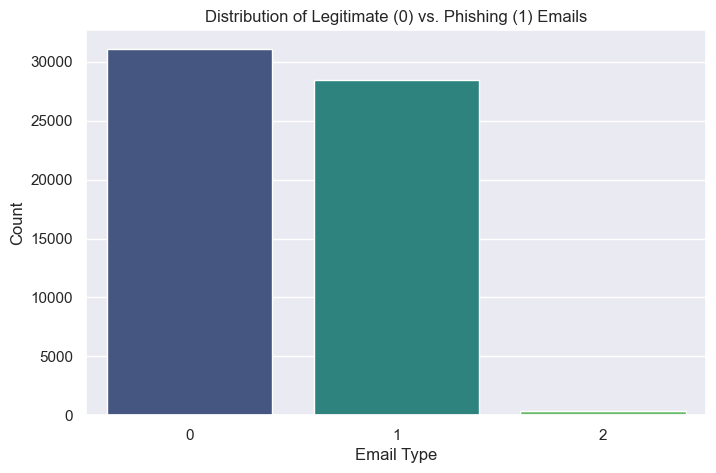

In [30]:
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Distribution of Legitimate (0) vs. Phishing (1) Emails')
plt.xlabel('Email Type')
plt.ylabel('Count')
plt.show()

## count of exclamation marks by type

C:\Users\abdul\AppData\Local\Temp\ipykernel_12128\176317278.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='excl_count', data=df, showfliers=False, palette='Set1')


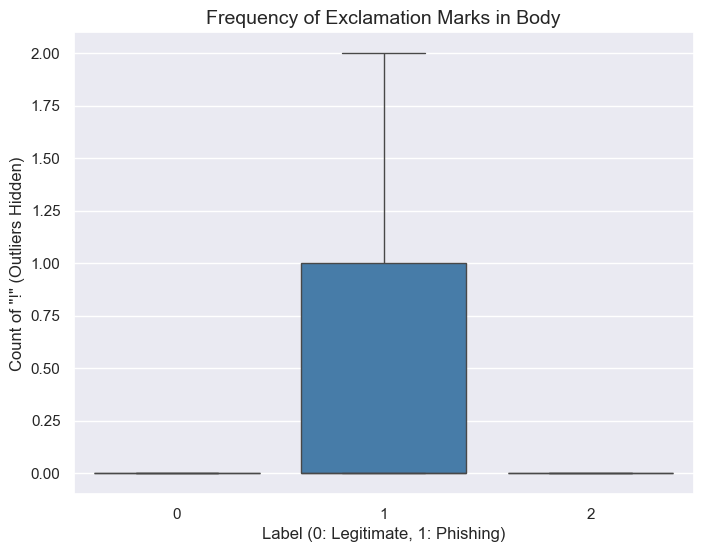

In [31]:
df['excl_count'] = df['body'].fillna('').apply(lambda x: x.count('!'))
plt.figure(figsize=(8, 6))
sns.boxplot(x='label', y='excl_count', data=df, showfliers=False, palette='Set1')
plt.title('Frequency of Exclamation Marks in Body', fontsize=14)
plt.xlabel('Label (0: Legitimate, 1: Phishing)')
plt.ylabel('Count of "!" (Outliers Hidden)')
plt.show()

## Subject length to Body length

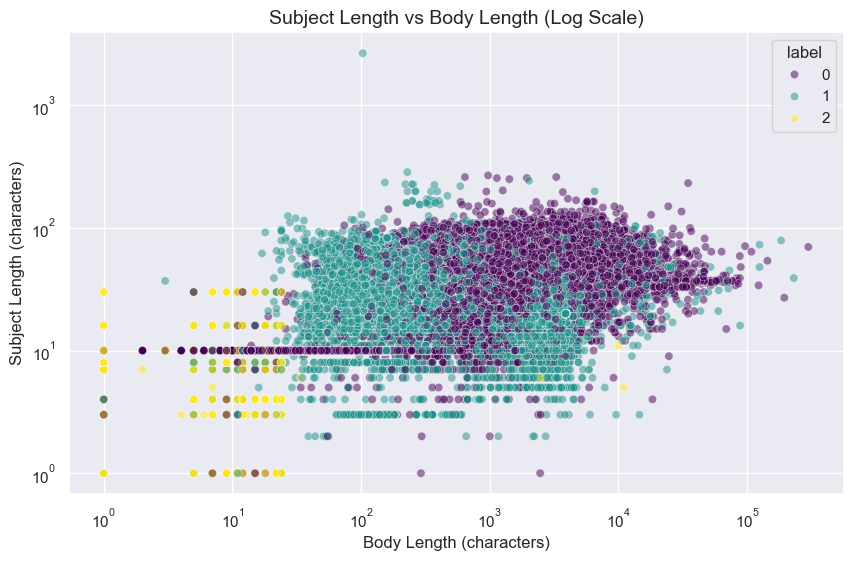

In [32]:
df['body_len'] = df['body'].fillna('').apply(len).replace(0, 1)
df['subject_len'] = df['subject'].fillna('').apply(len).replace(0, 1)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='body_len', y='subject_len', hue='label', alpha=0.5, palette='viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Subject Length vs Body Length (Log Scale)', fontsize=14)
plt.xlabel('Body Length (characters)')
plt.ylabel('Subject Length (characters)')
plt.show()

## Emails sent by time of day

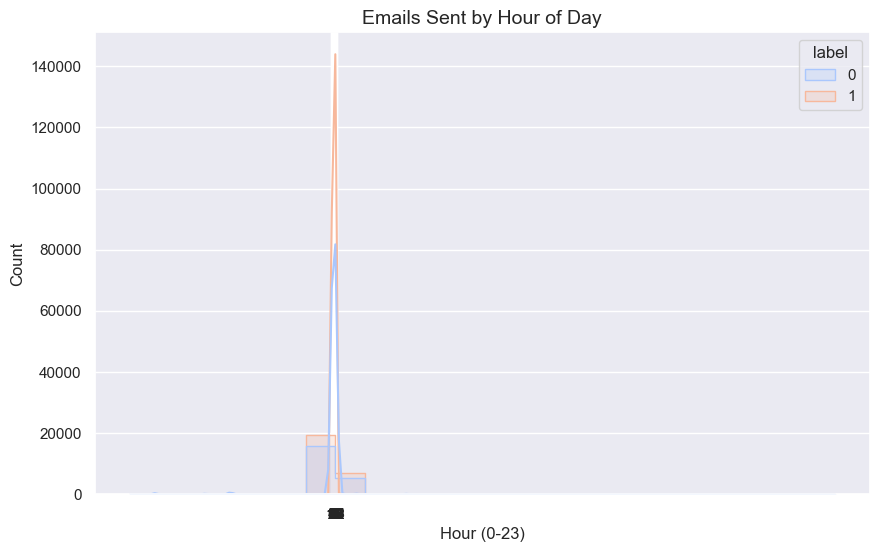

In [33]:
def parse_hour(date_str):
    try:
        parts = str(date_str).split()
        if len(parts) >= 5:
            return int(parts[4].split(':')[0])
    except:
        return np.nan
    return np.nan
df['hour'] = df['date'].apply(parse_hour)
plt.figure(figsize=(10, 6))
sns.histplot(data=df.dropna(subset=['hour']), x='hour', hue='label', bins=24, kde=True, palette='coolwarm', element='step')
plt.title('Emails Sent by Hour of Day', fontsize=14)
plt.xlabel('Hour (0-23)')
plt.xticks(range(0, 24))
plt.show()